In [46]:
from torchvision import transforms
from transformers import ViTForImageClassification
from transformers import AutoImageProcessor
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
from time import time
from tqdm import tqdm
import matplotlib.pyplot as plt
from ptflops import get_model_complexity_info
import seaborn as sns

In [2]:
processor=AutoImageProcessor.from_pretrained("google/vit-base-patch16-224")

# Architecture

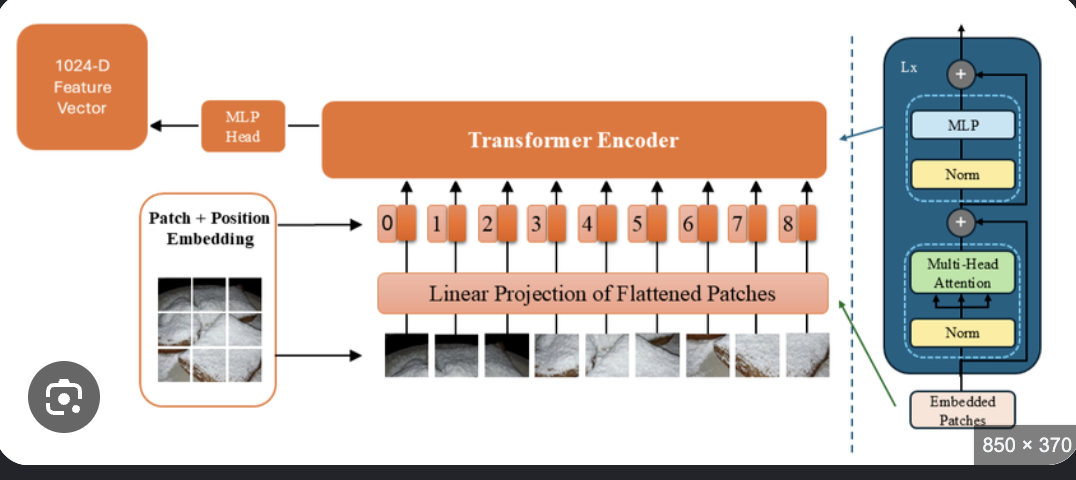

In [3]:
processor.image_mean

(0.5, 0.5, 0.5)

In [4]:
processor.image_std

(0.5, 0.5, 0.5)

In [ ]:
data_dir = "/path/to/data"

In [ ]:
dataset = ImageFolder(root=data_dir)

In [42]:
train_size = int(0.8 * len(dataset))

test_size = len(dataset) - train_size

train_subset, test_subset = random_split(dataset,[train_size, test_size],generator=torch.Generator().manual_seed(42))

In [ ]:
train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ColorJitter(

        brightness=0.2,

        contrast=0.2,

        saturation=0.2

    ),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=processor.image_mean,

        std=processor.image_std

    )

])

In [ ]:
test_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(

    mean=processor.image_mean,

    std=processor.image_std

    )

])

In [ ]:
train_dataset = torch.utils.data.Subset(

    ImageFolder(

        root=data_dir,

        transform=train_transform

    ),

    train_subset.indices

)

test_dataset = torch.utils.data.Subset(

    ImageFolder(

        root=data_dir,

        transform=test_transform

    ),

    test_subset.indices

)

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2
)
# num_workers controls how many CPU processes load images.
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2
)

In [7]:
model= ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=2,
    ignore_mismatched_sizes=True
)

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `1000`.
Loading weights: 100%|██████████| 200/200 [00:00<00:00, 10408.61it/s]
[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([2, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([2])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


### num_labels=2 replaces output size from 1000 (imagenet std) to 2

In [14]:
device= torch.device('mps')

In [15]:
model

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0-11): 12 x ViTLayer(
        (attention): ViTAttention(
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (o_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layernorm_before): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
        (layernorm_after): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
        (mlp): ViTMLP(
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear

In [16]:
model.classifier

Linear(in_features=768, out_features=2, bias=True)

In [17]:
device

device(type='mps')

In [18]:
model=model.to(device)

In [ ]:
loss= nn.CrossEntropyLoss()
optim= AdamW(model.parameters(),lr= 2e-5,weight_decay=0.01)
scheduler = CosineAnnealingLR(optim,T_max=10)

In [ ]:
epochs=10

In [ ]:
start = time()

for epoch in tqdm(range(epochs)):

    model.train()

    total = 0
    correct = 0
    epoch_loss = 0.0

    for imgs, labels in train_loader:

        imgs = imgs.to(device)

        labels = labels.to(device)

        outputs = model(imgs)

        logits= outputs.logits

        l = loss(
            logits,
            labels
        )

        optim.zero_grad()

        l.backward()

        optim.step()


        preds = torch.argmax(logits,dim=1)

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

        epoch_loss += l.item()

    print(
        f"Loss Epoch {epoch+1}: "
        f"{epoch_loss/len(train_loader):.4f}"
    )

    print(
        f"Accuracy Epoch {epoch+1}: "
        f"{100*correct/total:.2f}%"
    )

train_time = time() - start

In [ ]:
model.eval()

correct = 0
total = 0

LOSS = 0.0

all_preds = []
all_labels = []

start = time()

with torch.no_grad():

    for imgs, labels in test_loader:

        imgs = imgs.to(device)

        labels = labels.to(device)

        outputs = model(imgs)

        logits = outputs.logits

        l = loss(
            logits,
            labels
        )

        preds = torch.argmax(logits,dim=1)

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

        LOSS += l.item()

        all_preds.extend(
            preds.cpu().numpy().flatten()
        )

        all_labels.extend(
            labels.cpu().numpy().flatten()
        )

test_time = time() - start

print(
    f"Test Loss : "
    f"{LOSS/len(test_loader):.4f}"
)

print(
    f"Test Accuracy : "
    f"{100*correct/total:.2f}%"
)

print(
    f"Test Time : "
    f"{test_time:.2f}s"
)

## custom inference
#### file path -> pil image -> tensor -> unsqueeze(0) -> pass to model

In [ ]:
cls=["cat", "dog"]

In [ ]:
from PIL import Image
model.eval()
dog = Image.open("/kaggle/input/datasets/parth04pt/inference-cat-dog/dog.jpeg")
cat=Image.open("/kaggle/input/datasets/parth04pt/cat-2img/cat2.jpg")


In [47]:
infer_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=processor.image_mean,

        std=processor.image_std
    )
])

In [ ]:
cat_tensor = infer_transform(cat)
dog_tensor = infer_transform(dog)

In [ ]:
start= time()
outputs1 = model(dog_tensor.unsqueeze(0).to(device))
logits1 =outputs1.logits 
# (1,2) shape
probs1= torch.softmax(logits1,dim=1)
# (1,2 ) shape
pred1=probs1.argmax(probs1,dim=1).item()
# max prob along rows
confidence1 = probs1.max().item()
infer_time1 = time()- start

In [44]:
mean = torch.tensor(

    [0.485,0.456,0.406]

)

std = torch.tensor(

    [0.229,0.224,0.225]

)

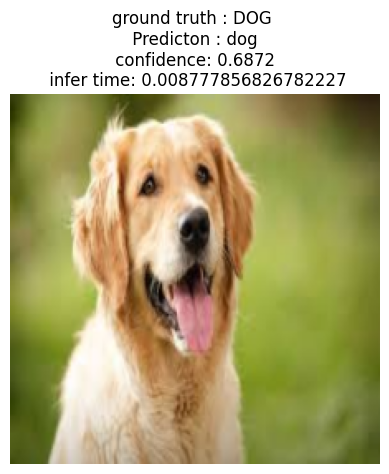

In [ ]:
plt.title(f"ground truth : DOG \n Predicton : {cls[pred1]} \n confidence: {confidence1:.4f} \n infer time: {infer_time1}")
img= dog_tensor.squeeze(0).cpu()
img = img * std.view(3,1,1).cpu() + mean.view(3,1,1).cpu()
img = img.clamp(0,1)
plt.imshow(img.permute(1,2,0))
plt.axis("off")
plt.show()

In [ ]:
start= time()
outputs2 = model(cat_tensor.unsqueeze(0).to(device))
logits2 =outputs2.logits 
# (1,2) shape
probs2= torch.softmax(logits2,dim=1)
# (1,2 ) shape
pred2=probs2.argmax(probs2,dim=1).item()
# max prob along rows
confidence2 = probs2.max().item()
infer_time2 = time()- start

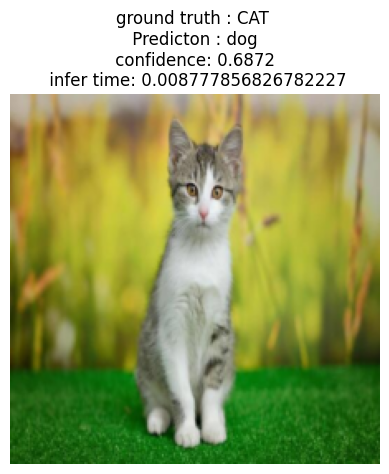

In [ ]:
plt.title(f"ground truth : CAT \n Predicton : {cls[pred2]} \n confidence: {confidence2:.4f} \n infer time: {infer_time2}")
img= cat_tensor.squeeze(0).cpu()
img = img * std.view(3,1,1).cpu() + mean.view(3,1,1).cpu()
img = img.clamp(0,1)
plt.imshow(img.permute(1,2,0))
plt.axis("off")
plt.show()

# METRICS

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

acc= accuracy_score(all_labels, all_preds)
pre = precision_score(all_labels, all_preds),
rec= recall_score(all_labels, all_preds)
f1= f1_score(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)

In [ ]:
num_paramerters=0
num_layers=0
for p in model.parameters():
    num_layers+=1
    num_paramerters+=p.numel()
    #weights
    #bias

In [ ]:
memory_usage= torch.cuda.memory_allocated()/1024**2

In [ ]:
macs, params = get_model_complexity_info(model,(3,224,224),as_strings=False,print_per_layer_stat=False)

In [ ]:
flops= macs*2

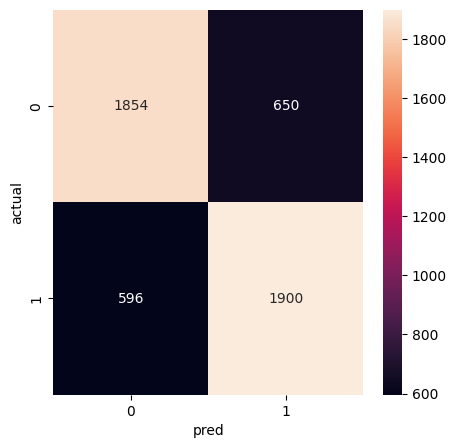

In [ ]:
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt= 'd')
plt.xlabel("pred")
plt.ylabel("actual")
plt.show()

In [ ]:
print("="*60)
print("VISION TRANSFORMER EVALUATION RESULTS")
print("="*60)

print(f"Model         : ViT-Base-Patch16-224")
print(f"Epochs        : {epochs}")

print()

print(f"Accuracy      : {acc:.4f}")
print(f"Precision     : {pre:.4f}")
print(f"Recall        : {rec:.4f}")
print(f"F1 Score      : {f1:.4f}")

print()

print(f"Training Time : {train_time:.2f}s")
print(f"Testing Time  : {test_time:.2f}s")

print()

print(f"Parameters    : {num_paramerters:,}")
print(f"FLOPs         : {flops:,.0f}")
print(f"Layers        : {num_layers}")
print(f"Memory Usage  : {memory_usage:.2f} MB")

print()

print("Classes       :", cls)

print()

print("Confusion Matrix")
print(cm)

print("="*60)

MODEL EVALUATION RESULTS
Epochs        : 20
Accuracy      : 0.7508
Precision     : 0.7451
Recall        : 0.7612
F1 Score      : 0.7531
Training Time : 2652.07s

Parameters    : 93,377
FLOPs         : 1040048386
Layers:       : 8
Memory Usage  : 60.77 MB

Classes       : ['cat', 'dog']

Confusion Matrix
[[1854  650]
 [ 596 1900]]
